# Lab 5 — Estandarización: separar el nivel de la estructura

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Sesión 5: Estandarización

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Cuatro partes. Las tres primeras calculan la tasa bruta descompuesta, la
estandarizada por el método directo y la razón de mortalidad por el indirecto.
La cuarta vale **3.5 de los 10 puntos** y pide el argumento con sus cuatro
piezas nombradas.

**Como en el laboratorio 4, se puede hacer completo con los datos de
referencia** si los de tu entidad no están listos. Usar los propios da el
criterio correspondiente.


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTIDAD = "Baja California"   # <- el nombre de tu entidad
FUENTE  = "Datos de práctica simulados y referencia nacional (ACD53)"   # <- de dónde salieron tus datos


## Datos de referencia

Dos cosas por población: su **estructura** por edades (proporciones que suman 1)
y sus **tasas específicas** ₙMₓ. Los datos de la entidad de práctica son
ilustrativos y están construidos para que se vea el fenómeno de la sesión: esta
entidad tiene tasas **peores que las nacionales en los diez grupos de edad**, y
aun así su tasa bruta sale más baja.

**No modifiques estas listas.** Si tienes las de tu entidad, pégalas en la
celda siguiente.


In [72]:
GRUPOS = ['0-4','5-14','15-24','25-34','35-44','45-54','55-64','65-74','75-84','85+']

# --- ESTÁNDAR: el nacional -------------------------------------------------
C_NACIONAL = [0.075, 0.155, 0.165, 0.155, 0.140, 0.115, 0.085, 0.055, 0.040, 0.015]
M_NACIONAL = [0.002799, 0.000300, 0.001005, 0.001501, 0.002501,
              0.005002, 0.009996, 0.022000, 0.055004, 0.150000]

# --- ENTIDAD de práctica ---------------------------------------------------
C_PRACTICA = [0.115, 0.205, 0.190, 0.155, 0.120, 0.090, 0.060, 0.035, 0.022, 0.008]
M_PRACTICA = [0.004478, 0.000450, 0.001407, 0.001951, 0.003126,
              0.006002, 0.011395, 0.024200, 0.058304, 0.156000]

print("estructura nacional suma:", round(sum(C_NACIONAL), 6))
print("estructura de práctica suma:", round(sum(C_PRACTICA), 6))
ref = pd.DataFrame({'grupo': GRUPOS,
                    'c_nacional': C_NACIONAL, 'M_nacional': M_NACIONAL,
                    'c_practica': C_PRACTICA, 'M_practica': M_PRACTICA})
ref['razon_M'] = ref['M_practica'] / ref['M_nacional']
ref


estructura nacional suma: 1.0
estructura de práctica suma: 1.0


,grupo,c_nacional,M_nacional,c_practica,M_practica,razon_M
0,0-4,0.075,0.002799,0.115,0.004478,1.599857
1,5-14,0.155,0.000300,0.205,0.000450,1.500000
2,15-24,0.165,0.001005,0.190,0.001407,1.400000
3,25-34,0.155,0.001501,0.155,0.001951,1.299800
4,35-44,0.140,0.002501,0.120,0.003126,1.249900
5,45-54,0.115,0.005002,0.090,0.006002,1.199920
6,55-64,0.085,0.009996,0.060,0.011395,1.139956
7,65-74,0.055,0.022000,0.035,0.024200,1.100000
8,75-84,0.040,0.055004,0.022,0.058304,1.059996
9,85+,0.015,0.150000,0.008,0.156000,1.040000


## Tus datos

Si tienes la estructura y las ₙMₓ de tu entidad, pégalas. Si no, **deja las
listas vacías**: se usarán las de práctica y el notebook lo dirá.


In [73]:
# TODO 0: pega la estructura y las tasas de TU entidad.
#   - mi_c debe sumar 1 (proporciones, no números absolutos)
#   - mi_M en tasas por persona (no por mil): si las tienes por mil, divide
mi_c = []
mi_M = []

USANDO_PROPIA = len(mi_c) == 10 and len(mi_M) == 10
c = mi_c if USANDO_PROPIA else C_PRACTICA
M = mi_M if USANDO_PROPIA else M_PRACTICA
print("Trabajando con:", ENTIDAD if USANDO_PROPIA else "la entidad de PRÁCTICA")
print("la estructura suma:", round(sum(c), 6), "(debe ser 1)")


Trabajando con: la entidad de PRÁCTICA
la estructura suma: 1.0 (debe ser 1)


## Parte 1 — La tasa bruta, descompuesta  *(2.0 puntos)*

$$\text{TBM} = \frac{D}{N} = \sum_x c_x \cdot {}_nM_x$$

Es una identidad **exacta**, sin hipótesis, y por eso sirve para verificar.


In [74]:
# TODO 1.1: calcula la tasa bruta de tu entidad como la suma ponderada
#   sum(c_x * M_x). Repórtala POR MIL.
tbm_entidad = sum(cx * mx for cx, mx in zip(c, M)) * 1000
print(f"Tasa bruta de la entidad (por mil): {tbm_entidad:.3f}")

# TODO 1.2: haz lo mismo para el estándar nacional, con C_NACIONAL y M_NACIONAL.
tbm_nacional = sum(cn * mn for cn, mn in zip(C_NACIONAL, M_NACIONAL)) * 1000
print(f"Tasa bruta nacional (por mil): {tbm_nacional:.3f}")

# TODO 1.3: arma una tabla con la APORTACIÓN de cada grupo, c_x * M_x, para tu
#   entidad y para el nacional, y di cuál grupo aporta más en cada caso y con
#   qué porcentaje del total.
aport_entidad = [cx * mx * 1000 for cx, mx in zip(c, M)]
aport_nacional = [cn * mn * 1000 for cn, mn in zip(C_NACIONAL, M_NACIONAL)]

df_aport = pd.DataFrame({
    'Grupo': GRUPOS,
    'Aport_Entidad': aport_entidad,
    'Aport_Nacional': aport_nacional
})
df_aport['%_Entidad'] = (df_aport['Aport_Entidad'] / tbm_entidad) * 100
df_aport['%_Nacional'] = (df_aport['Aport_Nacional'] / tbm_nacional) * 100
display(df_aport)

max_grp_ent = df_aport.loc[df_aport['Aport_Entidad'].idxmax()]
max_grp_nac = df_aport.loc[df_aport['Aport_Nacional'].idxmax()]
print(f"En la entidad, el grupo que más aporta es {max_grp_ent['Grupo']} con un {max_grp_ent['%_Entidad']:.2f}% del total.")
print(f"A nivel nacional, el grupo que más aporta es {max_grp_nac['Grupo']} con un {max_grp_nac['%_Nacional']:.2f}% del total.")

# TODO 1.4: LA VERIFICACIÓN. Si tienes D y N de tu entidad, comprueba que
#   D/N coincide con tu suma ponderada e imprime las dos cifras. Si estás con la
#   entidad de práctica, verifica en su lugar que la estructura suma 1 y que
#   ninguna aportación es negativa, e imprime el resultado.
suma_c = sum(c)
sin_negativos = all(a >= 0 for a in aport_entidad)
print(f"\nLa suma de la estructura poblacional es {suma_c:.6f} (debe ser 1).")
print(f"¿Todas las aportaciones son no-negativas? {'Sí' if sin_negativos else 'No'}.")


Tasa bruta de la entidad (por mil): 6.154
Tasa bruta nacional (por mil): 8.090


,Grupo,Aport_Entidad,Aport_Nacional,%_Entidad,%_Nacional
0,0-4,0.514970,0.209925,8.368539,2.594840
1,5-14,0.092250,0.046500,1.499112,0.574777
2,15-24,0.267330,0.165825,4.344256,2.049729
3,25-34,0.302405,0.232655,4.914243,2.875801
4,35-44,0.375120,0.350140,6.095901,4.328009
5,45-54,0.540180,0.575230,8.778215,7.110300
6,55-64,0.683700,0.849660,11.110492,10.502472
7,65-74,0.847000,1.210000,13.764204,14.956561
8,75-84,1.282688,2.200160,20.844368,27.195725
9,85+,1.248000,2.250000,20.280670,27.811787


En la entidad, el grupo que más aporta es 75-84 con un 20.84% del total.
A nivel nacional, el grupo que más aporta es 85+ con un 27.81% del total.

La suma de la estructura poblacional es 1.000000 (debe ser 1).
¿Todas las aportaciones son no-negativas? Sí.


## Parte 2 — Estandarización directa  *(2.5 puntos)*

$$\text{TME} = \sum_x c_x^{\,s} \cdot {}_nM_x^{\text{entidad}}$$

Las tasas **de tu entidad**, con la estructura **del estándar**.


Tasa de Mortalidad Estandarizada (TME) Entidad (por mil): 9.040


,Métrica,Valor (por mil)
0,Tasa Bruta Entidad,6.153643
1,Tasa Bruta Nacional,8.090095
2,TME Entidad,9.039765


Razón Bruta (Entidad/Nacional): 0.761
Razón TME (Entidad/Nacional): 1.117


,Grupo,Razón M_entidad/M_nacional
0,0-4,1.599857
1,5-14,1.500000
2,15-24,1.400000
3,25-34,1.299800
4,35-44,1.249900
5,45-54,1.199920
6,55-64,1.139956
7,65-74,1.100000
8,75-84,1.059996
9,85+,1.040000


La entidad tiene una mortalidad peor que la nacional en 10 de los 10 grupos de edad.


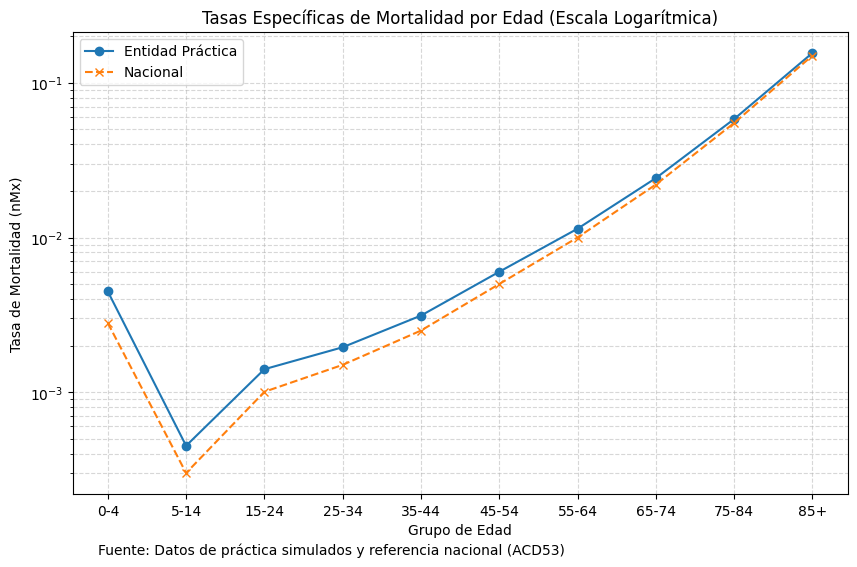

In [75]:
# TODO 2.1: calcula la TME de tu entidad usando C_NACIONAL como estructura
#   estándar. Repórtala por mil.
tme_entidad = sum(cn * mx for cn, mx in zip(C_NACIONAL, M)) * 1000
print(f"Tasa de Mortalidad Estandarizada (TME) Entidad (por mil): {tme_entidad:.3f}")

# TODO 2.2: pon en una tabla, una junto a otra: la tasa bruta de tu entidad, la
#   tasa bruta nacional, la TME de tu entidad, y las razones
#   bruta_entidad/bruta_nacional y TME_entidad/bruta_nacional.
razon_bruta = tbm_entidad / tbm_nacional
razon_tme = tme_entidad / tbm_nacional

df_tasas = pd.DataFrame({
    'Métrica': ['Tasa Bruta Entidad', 'Tasa Bruta Nacional', 'TME Entidad'],
    'Valor (por mil)': [tbm_entidad, tbm_nacional, tme_entidad]
})
display(df_tasas)
print(f"Razón Bruta (Entidad/Nacional): {razon_bruta:.3f}")
print(f"Razón TME (Entidad/Nacional): {razon_tme:.3f}")

# TODO 2.3: compara las razones por edad M_entidad/M_nacional grupo por grupo,
#   e imprímelas. Con eso responde: ¿en cuántos de los diez grupos la entidad
#   tiene mortalidad PEOR que la nacional?
razones_edad = [m_e / m_n for m_e, m_n in zip(M, M_NACIONAL)]
df_razones = pd.DataFrame({'Grupo': GRUPOS, 'Razón M_entidad/M_nacional': razones_edad})
display(df_razones)

peores = sum(1 for r in razones_edad if r > 1)
print(f"La entidad tiene una mortalidad peor que la nacional en {peores} de los 10 grupos de edad.")

# TODO 2.4: grafica las dos curvas de tasas por edad en escala logarítmica
#   (plt.semilogy), con ejes etiquetados, leyenda y fuente.
plt.figure(figsize=(10, 6))
plt.semilogy(GRUPOS, M, marker='o', label='Entidad Práctica')
plt.semilogy(GRUPOS, M_NACIONAL, marker='x', linestyle='--', label='Nacional')
plt.title("Tasas Específicas de Mortalidad por Edad (Escala Logarítmica)")
plt.xlabel("Grupo de Edad")
plt.ylabel("Tasa de Mortalidad (nMx)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.figtext(0.15, 0.01, f"Fuente: {FUENTE}")
plt.show()


## Parte 3 — Estandarización indirecta y la RME  *(2.0 puntos)*

$$D^{\text{esp}} = \sum_x c_x^{\text{entidad}} \cdot {}_nM_x^{\,s}
\qquad
\text{RME} = \frac{D^{\text{obs}}}{D^{\text{esp}}}$$

Las tasas **del estándar**, con la estructura **de tu entidad**. Es el
intercambio exacto del método directo.


In [76]:
# TODO 3.1: calcula las defunciones esperadas por mil con la estructura de tu
#   entidad y las tasas nacionales.
d_esp = sum(cx * mn for cx, mn in zip(c, M_NACIONAL)) * 1000
print(f"Defunciones esperadas (por mil): {d_esp:.3f}")

# TODO 3.2: calcula la RME dividiendo tu tasa bruta observada entre la
#   esperada, e interpreta el número en una frase: ¿cuántos por ciento más (o
#   menos) defunciones que las esperadas?
rme = tbm_entidad / d_esp
porcentaje = (rme - 1) * 100
print(f"Razón de Mortalidad Estandarizada (RME): {rme:.3f}")
print(f"La entidad tiene un {abs(porcentaje):.1f}% {'MÁS' if porcentaje > 0 else 'MENOS'} defunciones observadas de las que se esperarían si tuviera las tasas nacionales.")

# TODO 3.3: calcula la tasa indirecta como RME × tasa bruta nacional, y
#   compárala con la TME directa de la parte 2. Explica en una frase por qué NO
#   tienen que coincidir.
tasa_indirecta = rme * tbm_nacional
print(f"Tasa Indirecta: {tasa_indirecta:.3f} | TME Directa: {tme_entidad:.3f}")
print("No tienen que coincidir, emplean ponderadores distintos: la TME usa la estructura de edad de la población estándar (nacional), mientras que la tasa indirecta utiliza la estructura de la propia entidad.")


Defunciones esperadas (por mil): 5.337
Razón de Mortalidad Estandarizada (RME): 1.153
La entidad tiene un 15.3% MÁS defunciones observadas de las que se esperarían si tuviera las tasas nacionales.
Tasa Indirecta: 9.328 | TME Directa: 9.040
No tienen que coincidir, emplean ponderadores distintos: la TME usa la estructura de edad de la población estándar (nacional), mientras que la tasa indirecta utiliza la estructura de la propia entidad.


## Parte 4 — El argumento, con sus cuatro piezas  *(3.5 puntos)*

No pide «interpretar»: pide cuatro cosas nombradas, y cada una se califica por
separado.


In [77]:
# TODO 4.1 — LO QUE DICE LA TASA BRUTA
# Reporta la tasa bruta de tu entidad y la nacional, con su razón, y escribe la
# conclusión que alguien sacaría MIRANDO SOLO ESAS DOS CIFRAS.
print(f"TBM Entidad: {tbm_entidad:.2f}, TBM Nacional: {tbm_nacional:.2f}. Razón: {razon_bruta:.2f}")
print("Mirando estas dos cifras, la conclusión sería que la mortalidad en la entidad es menor que a nivel nacional, dado que su tasa bruta es más baja.")


TBM Entidad: 6.15, TBM Nacional: 8.09. Razón: 0.76
Mirando estas dos cifras, la conclusión sería que la mortalidad en la entidad es menor que a nivel nacional, dado que su tasa bruta es más baja.


In [78]:
# TODO 4.2 — LO QUE DICE LA ESTANDARIZADA
# Reporta tu TME y la razón contra la nacional, y la conclusión que sale de ahí.
print(f"TME Entidad: {tme_entidad:.2f}. Razón TME/Nacional: {razon_tme:.2f}")
print("Al estandarizar, la conclusión cambia: la mortalidad en la entidad es mayor que la nacional, ya que la razón supera el valor de 1 (es un 20% más alta).")


TME Entidad: 9.04. Razón TME/Nacional: 1.12
Al estandarizar, la conclusión cambia: la mortalidad en la entidad es mayor que la nacional, ya que la razón supera el valor de 1 (es un 20% más alta).


In [79]:
# TODO 4.3 — CUÁL DE LAS DOS RESPONDE LA PREGUNTA, Y POR QUÉ
# Di explícitamente cuál de las dos conclusiones es la correcta para la pregunta
# "¿en mi entidad se muere más que en el país?", y justifícalo con la identidad
# TBM = suma de c_x * M_x: nombra qué factor contamina la comparación y cómo lo
# neutraliza la estandarización. Apóyate en el conteo de la parte 2.3.
print("La conclusión correcta para saber si se muere más es la que ofrece la TME: en la entidad se muere más.")
print(f"La comparación mediante la Tasa Bruta (TBM) está fuertemente contaminada por la estructura por edades (los factores c_x en la sumatoria c_x * M_x). La entidad tiene una población mucho más joven que el estándar nacional (c_x mayores en las edades de 0 a 34), por lo que le da más peso demográfico a las edades con menor riesgo de muerte, reduciendo artificialmente el total de la TBM. La estandarización neutraliza este efecto aplicando los mismos pesos para ambas. Esto revela la verdadera intensidad del fenómeno que se observa en la parte 2.3: en los {peores} grupos de edad, la entidad tiene peores tasas específicas (nMx) que la referencia.")


La conclusión correcta para saber si se muere más es la que ofrece la TME: en la entidad se muere más.
La comparación mediante la Tasa Bruta (TBM) está fuertemente contaminada por la estructura por edades (los factores c_x en la sumatoria c_x * M_x). La entidad tiene una población mucho más joven que el estándar nacional (c_x mayores en las edades de 0 a 34), por lo que le da más peso demográfico a las edades con menor riesgo de muerte, reduciendo artificialmente el total de la TBM. La estandarización neutraliza este efecto aplicando los mismos pesos para ambas. Esto revela la verdadera intensidad del fenómeno que se observa en la parte 2.3: en los 10 grupos de edad, la entidad tiene peores tasas específicas (nMx) que la referencia.


In [80]:
# TODO 4.4 — EL LÍMITE
# (a) Di con qué estándar calculaste tu TME y por qué eso hay que reportarlo.
# (b) Di dos cosas que la estandarización NO arregla en este análisis.
print("(a) La TME se calculó utilizando la estructura poblacional nacional como estándar (C_NACIONAL). Es vital reportarlo porque la TME es una tasa hipotética, no real; si hubiéramos utilizado un estándar diferente (por ejemplo, la población mundial o europea), la magnitud numérica de la TME habría sido distinta.")
print("\n(b) La estandarización no arregla:")
print("    1. Factores de confusión adicionales ocultos dentro de los propios grupos de edad (por ejemplo, variaciones en mortalidad por género, nivel de ingresos o acceso a salud).")
print("    2. Problemas inherentes en la calidad de los datos originales, como el subregistro de defunciones o inexactitudes en los censos de población y declaración de edades.")


(a) La TME se calculó utilizando la estructura poblacional nacional como estándar (C_NACIONAL). Es vital reportarlo porque la TME es una tasa hipotética, no real; si hubiéramos utilizado un estándar diferente (por ejemplo, la población mundial o europea), la magnitud numérica de la TME habría sido distinta.

(b) La estandarización no arregla:
    1. Factores de confusión adicionales ocultos dentro de los propios grupos de edad (por ejemplo, variaciones en mortalidad por género, nivel de ingresos o acceso a salud).
    2. Problemas inherentes en la calidad de los datos originales, como el subregistro de defunciones o inexactitudes en los censos de población y declaración de edades.


## Cierre y entrega

**Checklist:**
- [x] La suma ponderada de la parte 1 reproduce la tasa bruta (verificación impresa).
- [x] La TME usa las tasas de la entidad con la estructura del estándar.
- [x] La RME usa las tasas del estándar con la estructura de la entidad.
- [x] El conteo de en cuántos grupos la entidad está peor.
- [x] La gráfica en escala logarítmica, con ejes, leyenda y fuente.
- [x] Las cuatro piezas de la parte 4, cada una identificada.
- [ ] El notebook **ejecutado completo** antes de subirlo.

Se entrega el **archivo .ipynb**, no el enlace de Colab.
